In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Loaded Successfully ✅")

Libraries Loaded Successfully ✅


In [3]:
transaction = pd.read_excel("data/Transaction.xlsx")
user = pd.read_excel("data/User.xlsx")
city = pd.read_excel("data/City.xlsx")
country = pd.read_excel("data/Country.xlsx")
region = pd.read_excel("data/Region.xlsx")
continent = pd.read_excel("data/Continent.xlsx")
item = pd.read_excel("data/Item.xlsx")
type_df = pd.read_excel("data/Type.xlsx")
mode = pd.read_excel("data/Mode.xlsx")

print("All Files Loaded Successfully ✅")

All Files Loaded Successfully ✅


In [4]:
print("Transaction Shape:", transaction.shape)
print("User Shape:", user.shape)

Transaction Shape: (52930, 7)
User Shape: (33530, 5)


In [5]:
print("Transaction Columns:", transaction.columns)
print("User Columns:", user.columns)
print("City Columns:", city.columns)
print("Country Columns:", country.columns)
print("Region Columns:", region.columns)
print("Continent Columns:", continent.columns)
print("Item Columns:", item.columns)
print("Type Columns:", type_df.columns)
print("Mode Columns:", mode.columns)

Transaction Columns: Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode',
       'AttractionId', 'Rating'],
      dtype='object')
User Columns: Index(['UserId', 'ContinentId', 'RegionId', 'CountryId', 'CityId'], dtype='object')
City Columns: Index(['CityId', 'CityName', 'CountryId'], dtype='object')
Country Columns: Index(['CountryId', 'Country', 'RegionId'], dtype='object')
Region Columns: Index(['Region', 'RegionId', 'ContinentId'], dtype='object')
Continent Columns: Index(['ContinentId', 'Continent'], dtype='object')
Item Columns: Index(['AttractionId', 'AttractionCityId', 'AttractionTypeId', 'Attraction',
       'AttractionAddress'],
      dtype='object')
Type Columns: Index(['AttractionTypeId', 'AttractionType'], dtype='object')
Mode Columns: Index(['VisitModeId', 'VisitMode'], dtype='object')


In [6]:
transaction.columns = transaction.columns.str.strip()
user.columns = user.columns.str.strip()
city.columns = city.columns.str.strip()
country.columns = country.columns.str.strip()
region.columns = region.columns.str.strip()
continent.columns = continent.columns.str.strip()
item.columns = item.columns.str.strip()
type_df.columns = type_df.columns.str.strip()
mode.columns = mode.columns.str.strip()

In [20]:
import pandas as pd

# Load all files
transaction = pd.read_excel("data/Transaction.xlsx")
user = pd.read_excel("data/User.xlsx")
city = pd.read_excel("data/City.xlsx")
country = pd.read_excel("data/Country.xlsx")
region = pd.read_excel("data/Region.xlsx")
continent = pd.read_excel("data/Continent.xlsx")
item = pd.read_excel("data/Item.xlsx")
type_df = pd.read_excel("data/Type.xlsx")

# -----------------------------
# STEP 1: Build Location Table
# -----------------------------

location = city.merge(country, on="CountryId", how="left")
location = location.merge(region, on="RegionId", how="left")
location = location.merge(continent, on="ContinentId", how="left")

# -----------------------------
# STEP 2: Merge Main Tables
# -----------------------------

# Transaction + User
data = transaction.merge(user, on="UserId", how="left")

# Add Item
data = data.merge(item, on="AttractionId", how="left")

# Add Type
data = data.merge(type_df, on="AttractionTypeId", how="left")

# Add Location using AttractionCityId
data = data.merge(location, left_on="AttractionCityId", right_on="CityId", how="left")

print("Final Shape:", data.shape)
data.head()

Final Shape: (52930, 24)


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating,ContinentId_x,RegionId_x,CountryId_x,...,AttractionAddress,AttractionType,CityId_y,CityName,CountryId_y,Country,RegionId_y,Region,ContinentId_y,Continent
0,3,70456,2022,10,2,640,5,5,21,163,...,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,1,Douala,1,Cameroon,1,Central Africa,1,Africa
1,8,7567,2022,10,4,640,5,2,8,48,...,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,1,Douala,1,Cameroon,1,Central Africa,1,Africa
2,9,79069,2022,10,3,640,5,2,9,54,...,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,1,Douala,1,Cameroon,1,Central Africa,1,Africa
3,10,31019,2022,10,3,640,3,5,17,135,...,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,1,Douala,1,Cameroon,1,Central Africa,1,Africa
4,15,43611,2022,10,2,640,3,5,21,163,...,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,1,Douala,1,Cameroon,1,Central Africa,1,Africa


In [21]:
# Keep only clean meaningful columns

data = data[[
    'UserId',
    'VisitYear',
    'VisitMonth',
    'VisitMode',
    'AttractionId',
    'Rating',
    'Attraction',
    'AttractionType',
    'CityName',
    'Country',
    'Region',
    'Continent'
]]

print("Cleaned Final Shape:", data.shape)
data.head()

Cleaned Final Shape: (52930, 12)


,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating,Attraction,AttractionType,CityName,Country,Region,Continent
0,70456,2022,10,2,640,5,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Douala,Cameroon,Central Africa,Africa
1,7567,2022,10,4,640,5,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Douala,Cameroon,Central Africa,Africa
2,79069,2022,10,3,640,5,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Douala,Cameroon,Central Africa,Africa
3,31019,2022,10,3,640,3,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Douala,Cameroon,Central Africa,Africa
4,43611,2022,10,2,640,3,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Douala,Cameroon,Central Africa,Africa


In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data['VisitMode'] = le.fit_transform(data['VisitMode'])
data['AttractionType'] = le.fit_transform(data['AttractionType'])
data['CityName'] = le.fit_transform(data['CityName'])
data['Country'] = le.fit_transform(data['Country'])
data['Region'] = le.fit_transform(data['Region'])
data['Continent'] = le.fit_transform(data['Continent'])

print("Encoding Done ✅")

Encoding Done ✅


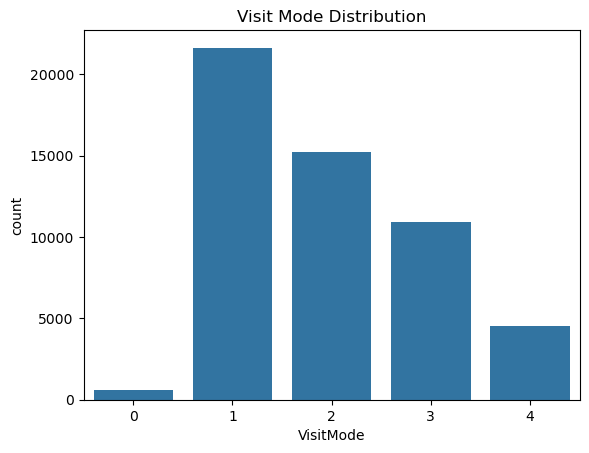

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='VisitMode', data=data)
plt.title("Visit Mode Distribution")
plt.show()

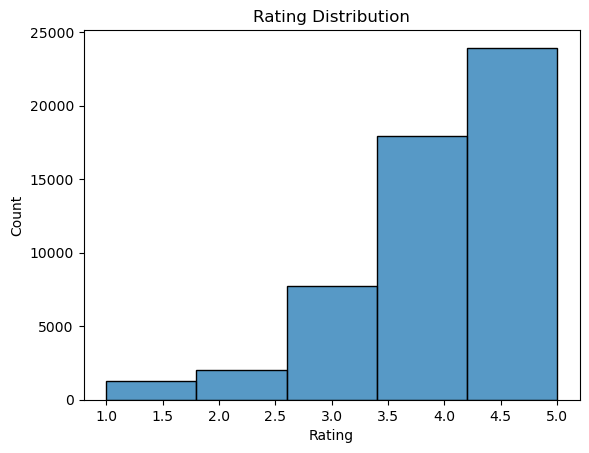

In [33]:
sns.histplot(data['Rating'], bins=5)
plt.title("Rating Distribution")
plt.show()

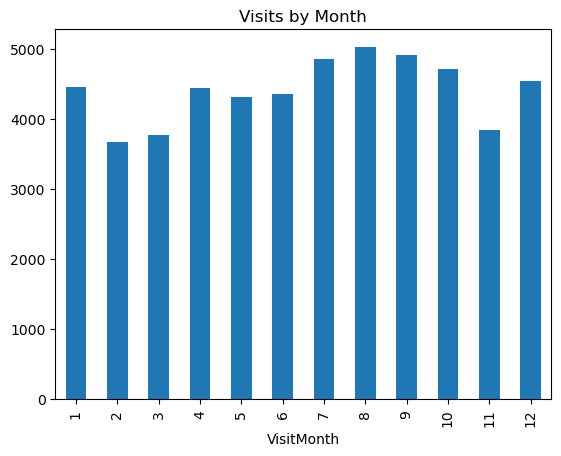

In [34]:
data.groupby("VisitMonth")["UserId"].count().plot(kind="bar")
plt.title("Visits by Month")
plt.show()

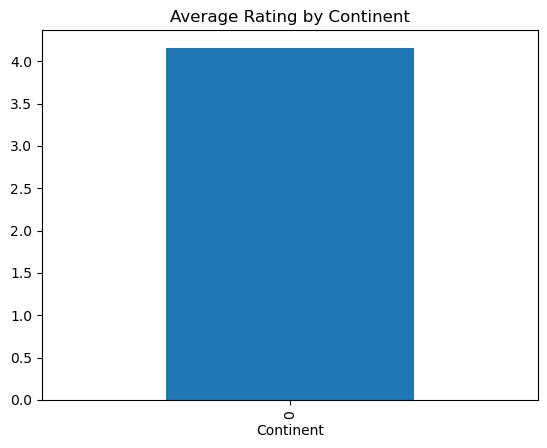

In [35]:
data.groupby("Continent")["Rating"].mean().plot(kind="bar")
plt.title("Average Rating by Continent")
plt.show()

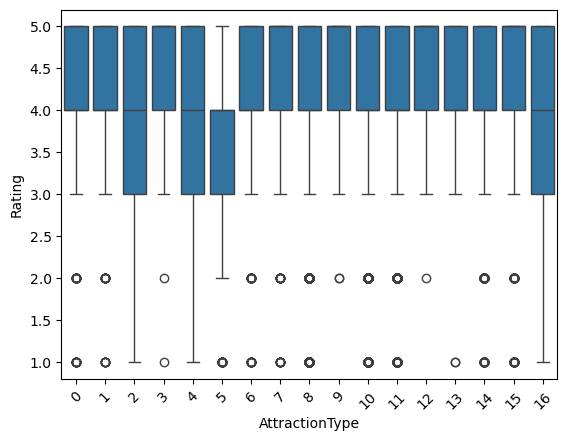

In [36]:
sns.boxplot(x="AttractionType", y="Rating", data=data)
plt.xticks(rotation=45)
plt.show()

In [23]:
X = data[['VisitYear','VisitMonth','VisitMode',
          'AttractionType','CityName',
          'Country','Region','Continent']]

y = data['Rating']

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Train Shape:", X_train.shape)

Train Shape: (42344, 8)


In [25]:
from sklearn.ensemble import RandomForestRegressor

reg_model = RandomForestRegressor()
reg_model.fit(X_train, y_train)

print("Regression Model Trained ✅")

Regression Model Trained ✅


In [26]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = reg_model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.04364294911921751
MSE: 0.9007125568487465


In [27]:
X = data[['VisitYear','VisitMonth',
          'AttractionType','CityName',
          'Country','Region','Continent']]

y = data['VisitMode']

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [29]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

print("Classifier Trained ✅")

Classifier Trained ✅


In [30]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.46410353296807105
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       130
           1       0.46      0.82      0.59      4290
           2       0.52      0.35      0.42      3079
           3       0.38      0.11      0.17      2171
           4       0.34      0.07      0.12       916

    accuracy                           0.46     10586
   macro avg       0.34      0.27      0.26     10586
weighted avg       0.45      0.46      0.41     10586



In [38]:
user_item = data.pivot_table(
    index='UserId',
    columns='Attraction',
    values='Rating'
).fillna(0)

print(user_item.shape)

(33530, 30)


In [39]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(user_item)

print("Similarity Matrix Created ✅")

Similarity Matrix Created ✅


In [40]:
import numpy as np

def recommend_attractions(user_id, top_n=5):
    
    if user_id not in user_item.index:
        return "User not found"
    
    user_index = user_item.index.get_loc(user_id)
    
    similarity_scores = list(enumerate(similarity[user_index]))
    
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)
    
    similar_users = [user_item.index[i[0]] for i in similarity_scores[1:6]]
    
    recommended = user_item.loc[similar_users].mean().sort_values(ascending=False)
    
    return recommended.head(top_n)

In [43]:
recommend_attractions(user_item.index[0])

Attraction
Tegalalang Rice Terrace               5.0
Sacred Monkey Forest Sanctuary        4.0
Balekambang Beach                     0.0
Bromo Tengger Semeru National Park    0.0
Waterbom Bali                         0.0
dtype: float64

In [ ]:
Business Insights

• Majority of users prefer specific Visit Modes indicating dominant travel behavior.
• Ratings are mostly high (4–5), indicating positive tourism experience.
• Seasonal trends show higher visits in certain months.
• Certain attraction types consistently receive higher ratings.
• Recommendation system can improve customer retention and personalized marketing.

In [45]:
import pickle
pickle.dump(reg_model, open("reg_model.pkl", "wb"))

In [46]:
import os
os.getcwd()

'C:\\Users\\Vanaja\\Tourism_Experience_Analytics.2f831b58-0974-4a64-ac76-704b742775f4'

In [47]:
import pickle

pickle.dump(reg_model, open("reg_model.pkl", "wb"))
pickle.dump(clf, open("clf_model.pkl", "wb"))

In [48]:
print(data['VisitMode'].unique())
print(data['AttractionType'].unique())
print(data['CityName'].unique())
print(data['Country'].unique())
print(data['Region'].unique())
print(data['Continent'].unique())

[1 3 2 4 0]
[ 8 15  2 11 10 16  7 14  9 13 12  3  4  1  0  6  5]
[0 2 1]
[0 1]
[0]
[0]


In [49]:
data.to_csv("final_cleaned_data.csv", index=False)